<a href="https://colab.research.google.com/github/Nikhilesh-Nanda/House-Price-Predictor/blob/main/HOUSE_PRICE_PREDICTOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A basic level project that will predict the house price of a city or location

# **DOWNLOAD THE DATASET**

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Path to dataset files: /kaggle/input/housing-prices-dataset


# **GET A TASTE OF DATASET**

In [2]:
import pandas as pd

my_data = pd.read_csv("/kaggle/input/housing-prices-dataset/Housing.csv")

display(my_data.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
my_data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [4]:
dimensions = my_data.shape
rows = dimensions[0]
cols = dimensions[1]

print("ROWS=",rows)
print("COLS=",cols)

ROWS= 545
COLS= 13


In [5]:
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


# **Convert all the yes/no values to binary(0 or 1) for ease**

In order to do that, we first will use label encoder as the datatype is object,and then fit_transform, which will first evaluate the parameters, and then normalise in the range [0,1]

In [25]:
from sklearn.preprocessing import LabelEncoder

yes_no_columns = []
for col in my_data.columns:
    if my_data[col].dtype == 'object': # Only check object type columns
        unique_values = set(my_data[col].unique())
        if unique_values == {'yes', 'no'}:
            yes_no_columns.append(col)

print("Columns with only 'yes'/'no' values:", yes_no_columns)

lb = LabelEncoder()
for col in yes_no_columns:
  my_data[col] = lb.fit_transform(my_data[col])

display(my_data.head())

Columns with only 'yes'/'no' values: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_per_sqft
0,13300,7420,4,2,3,1,0,0,0,1,2,1,1,1.792453
1,12250,8960,4,4,4,1,0,0,0,1,3,0,1,1.367188
2,12250,9960,3,2,2,1,0,1,0,0,2,1,0,1.229920
3,12215,7500,4,2,2,1,0,1,0,1,3,1,1,1.628667
4,11410,7420,4,1,2,1,1,1,0,1,2,0,1,1.537736


# **EDA**

# **Furnishing conditions**

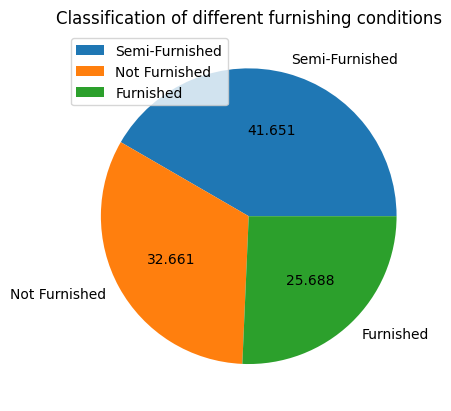

In [7]:
import matplotlib.pyplot as plt

pieContent = ['Semi-Furnished','Not Furnished','Furnished']
y = my_data.furnishingstatus.value_counts()

plt.pie(y,labels=pieContent,autopct="%0.3f")

plt.title("Classification of different furnishing conditions")
plt.legend()
plt.grid(True)
plt.show()

# **Air conditioning status**

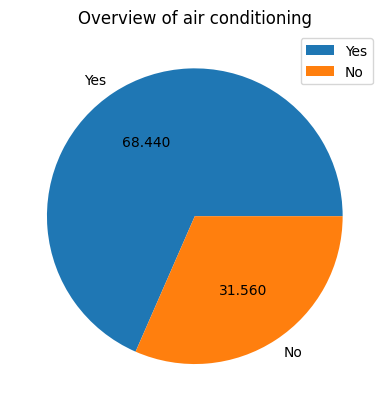

In [8]:
import matplotlib.pyplot as plt

pieContent = ['Yes','No']
uniqueCountsPerClass = my_data['airconditioning'].value_counts()

pieChart = plt.pie(uniqueCountsPerClass,labels = pieContent, autopct="%0.3f")

plt.title("Overview of air conditioning")
plt.legend()
plt.show()

# **Main Road**

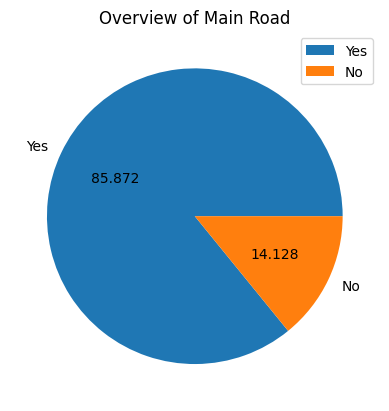

In [9]:
import matplotlib.pyplot as plt

pieContent = ['Yes','No']
uniqueCountsPerClass = my_data['mainroad'].value_counts()

pieChart = plt.pie(uniqueCountsPerClass,labels = pieContent, autopct="%0.3f")

plt.title("Overview of Main Road")
plt.legend()
plt.show()

In [10]:
import pandas as pd

my_data = pd.read_csv("/kaggle/input/housing-prices-dataset/Housing.csv")

display(my_data.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# **Basement**

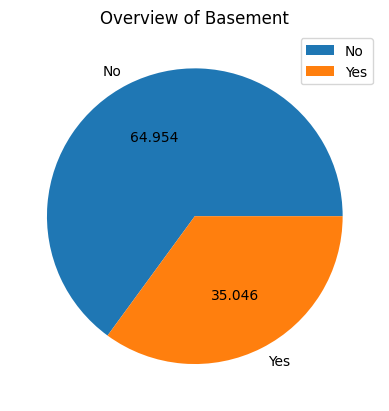

In [11]:
import matplotlib.pyplot as plt

pieContent = ['No','Yes']
uniqueCountsPerClass = my_data['basement'].value_counts()

pieChart = plt.pie(uniqueCountsPerClass,labels = pieContent, autopct="%0.3f")

plt.title("Overview of Basement")
plt.legend()
plt.show()

# **Hot Water Heating**

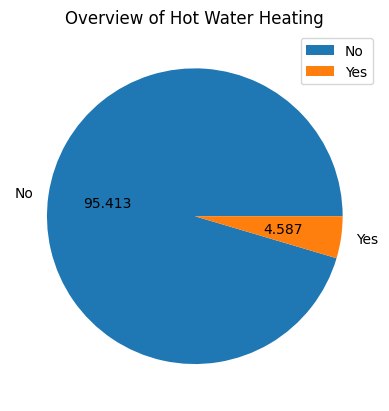

In [12]:
import matplotlib.pyplot as plt

pieContent = ['No','Yes']
uniqueCountsPerClass = my_data['hotwaterheating'].value_counts()

pieChart = plt.pie(uniqueCountsPerClass,labels = pieContent, autopct="%0.3f")

plt.title("Overview of Hot Water Heating")
plt.legend()
plt.show()

# **GUEST ROOM**

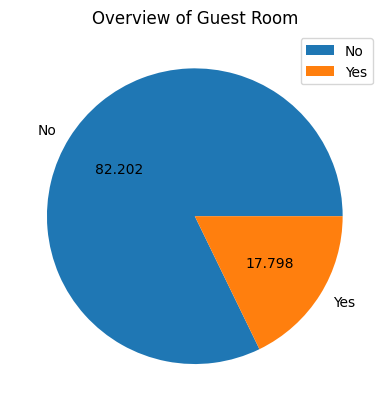

In [13]:
import matplotlib.pyplot as plt

pieContent = ['No','Yes']
uniqueCountsPerClass = my_data['guestroom'].value_counts()

pieChart = plt.pie(uniqueCountsPerClass,labels = pieContent, autopct="%0.3f")

plt.title("Overview of Guest Room")
plt.legend()
plt.show()

# **Pref Area**

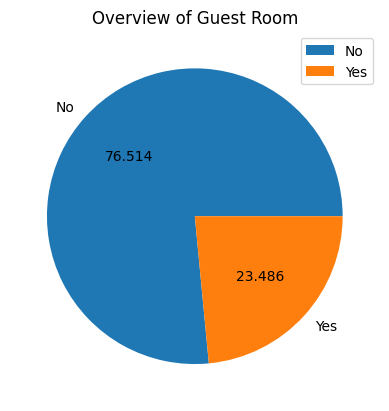

In [14]:
import matplotlib.pyplot as plt

pieContent = ['No','Yes']
uniqueCountsPerClass = my_data['prefarea'].value_counts()

pieChart = plt.pie(uniqueCountsPerClass,labels = pieContent, autopct="%0.3f")

plt.title("Overview of Guest Room")
plt.legend()
plt.show()

In [15]:
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [16]:
my_data['price'] = my_data['price']//1000

In [17]:
my_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# **Converting furnishing status to 0,0.5 and 1**

In [19]:
status_mapping = {
    'furnished': 1,
    'semi-furnished': 0.5,
    'unfurnished': 0
}
my_data['furnishingstatus'] = my_data['furnishingstatus'].map(status_mapping)
display(my_data)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300,7420,4,2,3,yes,no,no,no,yes,2,yes,1.0
1,12250,8960,4,4,4,yes,no,no,no,yes,3,no,1.0
2,12250,9960,3,2,2,yes,no,yes,no,no,2,yes,0.5
3,12215,7500,4,2,2,yes,no,yes,no,yes,3,yes,1.0
4,11410,7420,4,1,2,yes,yes,yes,no,yes,2,no,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820,3000,2,1,1,yes,no,yes,no,no,2,no,0.0
541,1767,2400,3,1,1,no,no,no,no,no,0,no,0.5
542,1750,3620,2,1,1,yes,no,no,no,no,0,no,0.0
543,1750,2910,3,1,1,no,no,no,no,no,0,no,1.0


In [20]:
my_data['furnishingstatus'] = my_data['furnishingstatus'].astype(int)

In [26]:
my_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_per_sqft
0,13300,7420,4,2,3,1,0,0,0,1,2,1,1,1.792453
1,12250,8960,4,4,4,1,0,0,0,1,3,0,1,1.367188
2,12250,9960,3,2,2,1,0,1,0,0,2,1,0,1.229920
3,12215,7500,4,2,2,1,0,1,0,1,3,1,1,1.628667
4,11410,7420,4,1,2,1,1,1,0,1,2,0,1,1.537736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820,3000,2,1,1,1,0,1,0,0,2,0,0,0.606667
541,1767,2400,3,1,1,0,0,0,0,0,0,0,0,0.736250
542,1750,3620,2,1,1,1,0,0,0,0,0,0,0,0.483425
543,1750,2910,3,1,1,0,0,0,0,0,0,0,1,0.601375


# **Making the model**

# **Creating a new features : Price Per Square Feet**

In [22]:
from math import floor
my_data['price_per_sqft'] = my_data['price']/my_data['area']

In [23]:
display(my_data)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_per_sqft
0,13300,7420,4,2,3,yes,no,no,no,yes,2,yes,1,1.792453
1,12250,8960,4,4,4,yes,no,no,no,yes,3,no,1,1.367188
2,12250,9960,3,2,2,yes,no,yes,no,no,2,yes,0,1.229920
3,12215,7500,4,2,2,yes,no,yes,no,yes,3,yes,1,1.628667
4,11410,7420,4,1,2,yes,yes,yes,no,yes,2,no,1,1.537736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820,3000,2,1,1,yes,no,yes,no,no,2,no,0,0.606667
541,1767,2400,3,1,1,no,no,no,no,no,0,no,0,0.736250
542,1750,3620,2,1,1,yes,no,no,no,no,0,no,0,0.483425
543,1750,2910,3,1,1,no,no,no,no,no,0,no,1,0.601375


# **Linear Regression**

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,accuracy_score
from sklearn.model_selection import train_test_split

X = my_data[['area','bedrooms','bathrooms','stories','mainroad'	,'guestroom','basement','hotwaterheating','airconditioning','parking','prefarea','furnishingstatus']]
Y = my_data['price']

lr = LinearRegression()

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=1234)

lr.fit(X_train,Y_train)

y_pred = lr.predict(X_test)

print(r2_score(Y_test,y_pred))

0.6355012872096276


# **DECISION TREES**

In [28]:
from sklearn.tree import DecisionTreeRegressor # Changed from DecisionTreeClassifier
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor



X = my_data[['area','bedrooms','bathrooms','mainroad','guestroom','basement','airconditioning','parking','prefarea','furnishingstatus']]
X1 = my_data[['area','bedrooms','bathrooms','stories','mainroad','guestroom','basement','hotwaterheating','airconditioning','parking','prefarea','furnishingstatus']]
Y = my_data['price']

rr = RandomForestRegressor()
dt = DecisionTreeRegressor() # Changed from DecisionTreeClassifier
gb= GradientBoostingRegressor()

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=1234)
X1_train,X1_test,Y1_train,Y1_test = train_test_split(X1,Y,test_size=0.2,random_state=1234)


dt.fit(X_train,Y_train)
rr.fit(X_train,Y_train)
gb.fit(X_train,Y_train)

y_pred1 = dt.predict(X_test)
y_pred2 = rr.predict(X_test)
y_pred3 = gb.predict(X_test)

print("RANDOM FOREST REGRESSOR: R2 SCORE=",r2_score(Y_test,y_pred2))
print("DECISION TREE: R2 SCORE=", r2_score(Y_test,y_pred1))
print("GRADIENT BOOST REGRESSOR: R2 SCORE=", r2_score(Y_test,y_pred3))

RANDOM FOREST REGRESSOR: R2 SCORE= 0.5316097099365563
DECISION TREE: R2 SCORE= 0.23854746819312267
GRADIENT BOOST REGRESSOR: R2 SCORE= 0.5159158449017109


# **FINE TUNINNG THE MODEL**

In [29]:
import pandas as pd

my_data = pd.read_csv("/kaggle/input/housing-prices-dataset/Housing.csv")
display(my_data.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Applying one hot encoding instead of label encoding which is generally a more robust approach for machine learning models as it prevents the model from assuming an ordinal relationship between categories where none exists

In [30]:
my_data['price'] = my_data['price'] // 1000

# Identify categorical columns
categorical_cols = my_data.select_dtypes(include='object').columns

# Apply one-hot encoding to all identified categorical columns
my_data = pd.get_dummies(my_data, columns=categorical_cols, drop_first=True, dtype=int)

# Create 'price_per_sqft' feature
my_data['price_per_sqft'] = my_data['price'] / my_data['area']

display(my_data.head())


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,price_per_sqft
0,13300,7420,4,2,3,2,1,0,0,0,1,1,0,0,1.792453
1,12250,8960,4,4,4,3,1,0,0,0,1,0,0,0,1.367188
2,12250,9960,3,2,2,2,1,0,1,0,0,1,1,0,1.229920
3,12215,7500,4,2,2,3,1,0,1,0,1,1,0,0,1.628667
4,11410,7420,4,1,2,2,1,1,1,0,1,0,0,0,1.537736


In [31]:
X = my_data[['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'parking', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished', 'price_per_sqft']]
Y = my_data['price']

print("Features (X) shape:", X.shape)
print("Target (Y) shape:", Y.shape)


Features (X) shape: (545, 14)
Target (Y) shape: (545,)


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1234)

# Instantiate the models
lr_model = LinearRegression()
dt_model = DecisionTreeRegressor(random_state=1234)
rf_model = RandomForestRegressor(random_state=1234)
gb_model = GradientBoostingRegressor(random_state=1234)

# Train the models
lr_model.fit(X_train, Y_train)
dt_model.fit(X_train, Y_train)
rf_model.fit(X_train, Y_train)
gb_model.fit(X_train, Y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

# Calculate and print R2 scores
print(f"Linear Regression R2 Score: {r2_score(Y_test, y_pred_lr):.4f}")
print(f"Decision Tree Regressor R2 Score: {r2_score(Y_test, y_pred_dt):.4f}")
print(f"Random Forest Regressor R2 Score: {r2_score(Y_test, y_pred_rf):.4f}")
print(f"Gradient Boosting Regressor R2 Score: {r2_score(Y_test, y_pred_gb):.4f}")

Linear Regression R2 Score: 0.8698
Decision Tree Regressor R2 Score: 0.9119
Random Forest Regressor R2 Score: 0.8904
Gradient Boosting Regressor R2 Score: 0.9052


Here, we can see that the Decision Tree Regressor performed better than other models. So, while plotting the actual and predicted values of price, we are using y_test, which is unknown to model to test it's adaptability

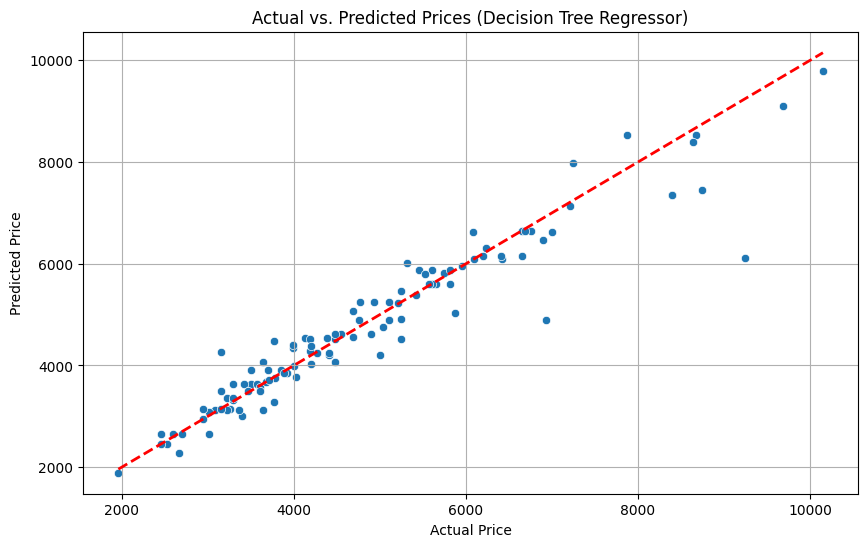

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify the best performing model (Decision Tree Regressor based on previous output)
best_model_name = "Decision Tree Regressor"
best_y_pred = y_pred_dt # Using y_pred_dt from the previous step

plt.figure(figsize=(10, 6))
sns.scatterplot(x=Y_test, y=best_y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], '--r', linewidth=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs. Predicted Prices ({best_model_name})")
plt.grid(True)
plt.show()


# **Saving the model**

In [38]:
import pickle

f = open("model.pkl","wb")
pickle.dump(dt_model,f)
f.close()